
- Calving Fronts
    * Description: Time-evolving Antarctic calving fronts from observations.
    * Original Data Source: https://zenodo.org/records/5903643
    * Reference: https://www.nature.com/articles/s41586-022-05037-w
    * OSC entry: https://opensciencedata.esa.int/products/antarctic-ice-shelf-calving-fronts/collection
    * License: CC-BY-4.0
    * Repo Folder: ./datasets/calving_fronts

In [6]:
import geopandas as gpd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np

bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet'

In [2]:
gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)
gdf['area'] = gdf.area

In [3]:
largest_polygon = gdf.sort_values(['time', 'area'], ascending=False).groupby('time').first()
largest_polygon

,geometry,area
time,,
1997-10-01,"POLYGON ((2750273 -284633, 2750153 -284753, 27...",1.365215e+13
2000-03-14,"POLYGON ((2750753 -284153, 2750633 -284273, 27...",1.363662e+13
2000-10-01,"POLYGON ((2750753 -286793, 2750633 -286913, 27...",1.362348e+13
2001-03-15,"POLYGON ((2750513 -283913, 2750393 -284033, 27...",1.361862e+13
2002-03-15,"POLYGON ((2750753 -283913, 2750633 -284033, 27...",1.361781e+13
2003-03-15,"POLYGON ((2750993 -283673, 2750873 -283793, 27...",1.361558e+13
2004-03-14,"POLYGON ((2751233 -283673, 2751113 -283793, 27...",1.361330e+13
2005-03-15,"POLYGON ((2751473 -283433, 2751353 -283553, 27...",1.361590e+13
2006-03-15,"POLYGON ((2751713 -282713, 2751593 -282833, 27...",1.361750e+13


In [16]:
def plot_polygon_shrink_over_time(
    gdf,
    time_col="time",
    geometry_col="geometry",
    cmap="viridis",
    fill_alpha=0.05,
    edge_alpha=0.9,
    linewidth=1.5,
    figsize=(8, 8),
):
    """
    Plot polygon geometries overlaid through time.

    Earlier geometries and later geometries are colored using a time-based colormap.
    Works with Polygon and MultiPolygon geometries.
    """

    # Copy so the original GeoDataFrame is not modified
    gdf_plot = gdf.copy()

    # Make sure geometry column is active
    gdf_plot = gdf_plot.set_geometry(geometry_col)

    # Make sure time is datetime
    gdf_plot[time_col] = gpd.pd.to_datetime(gdf_plot[time_col])

    # Sort from earliest to latest
    gdf_plot = gdf_plot.sort_values(time_col)

    # Drop missing geometry or time values
    gdf_plot = gdf_plot.dropna(subset=[time_col, geometry_col])

    # Convert datetimes to numeric values for matplotlib colormap
    time_nums = mdates.date2num(gdf_plot[time_col])
    norm = Normalize(vmin=time_nums.min(), vmax=time_nums.max())
    colormap = plt.get_cmap(cmap)

    fig, ax = plt.subplots(figsize=figsize)

    # Plot each geometry in time order
    for _, row in gdf_plot.iterrows():
        t_num = mdates.date2num(row[time_col])
        color = colormap(norm(t_num))

        gpd.GeoSeries([row.geometry], crs=gdf_plot.crs).plot(
            ax=ax,
            facecolor=color,
            edgecolor=color,
            alpha=fill_alpha,
            linewidth=linewidth,
        )

        # Draw a stronger boundary on top
        gpd.GeoSeries([row.geometry], crs=gdf_plot.crs).boundary.plot(
            ax=ax,
            color=color,
            alpha=edge_alpha,
            linewidth=linewidth,
        )

    # Add colorbar showing time
    sm = ScalarMappable(norm=norm, cmap=colormap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(time_col)

    # Format colorbar as dates
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    ax.set_title("Polygon shrinkage through time")
    ax.set_aspect("equal")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    plt.tight_layout()
    return fig, ax

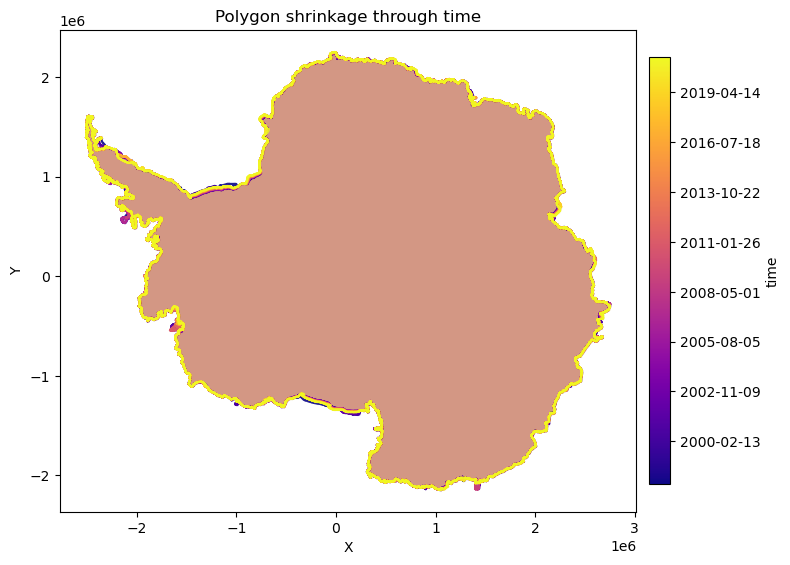

In [17]:
fig, ax = plot_polygon_shrink_over_time(
    # go from present to past, since the total area is shrinking
    largest_polygon.reset_index(),
    time_col="time",
    geometry_col="geometry",
    cmap="plasma"
)

plt.show()